<a href="https://colab.research.google.com/github/sonia73b/tech405asst/blob/main/TECH405.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training shape: (25000, 300)
Testing shape: (25000, 300)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 300, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,704,257 (10.32 MB)

 Trainable params: 2,704,257 (10.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.7825 - loss: 0.4307 - val_accuracy: 0.8670 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9255 - loss: 0.2002 - val_accuracy: 0.8890 - val_loss: 0.2775 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9662 - loss: 0.1017
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9635 - loss: 0.1069 - val_accuracy: 0.8764 - val_loss: 0.3290 - learning_rate: 0.0010
Epoch 4/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9875 - loss: 0.0434
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9873 - loss: 0.0433 - val_accuracy: 0.8748 - val_loss: 0.4442 - learning_rate: 5.0000e-04
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8700 - loss: 0.3080

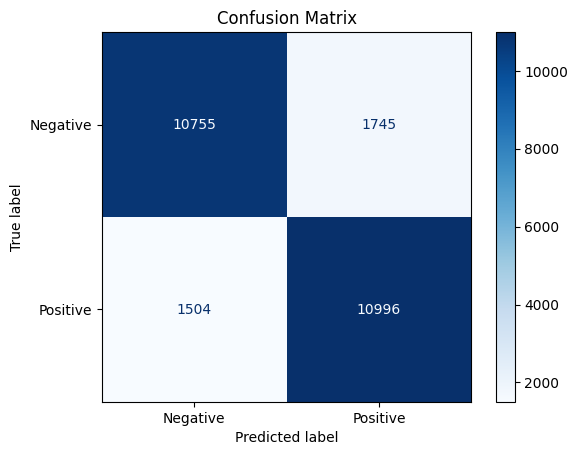

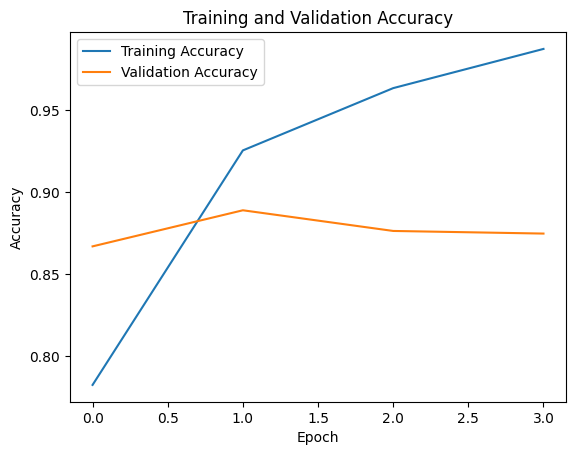

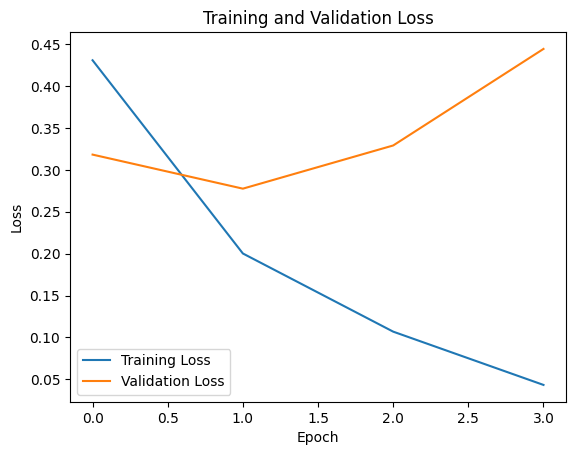

Review: this movie was amazing and inspiring
Predicted Sentiment: Positive (0.8439)

Review: i hated this movie it was boring and slow
Predicted Sentiment: Negative (0.0300)

Review: the acting was fantastic and the story was touching
Predicted Sentiment: Positive (0.8854)

Review: this film was a complete waste of time
Predicted Sentiment: Negative (0.0338)

Review: this movie made my day
Predicted Sentiment: Positive (0.7084)



In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.layers import GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Parameters
VOCAB_SIZE = 20000
MAX_LENGTH = 300
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 10

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Pad sequences
X_train_padded = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post', truncating='post')

print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)

# Build improved model
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    verbose=1
)

# Train
history = model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Predictions
y_pred_prob = model.predict(X_test_padded)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Accuracy plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Decode word index for custom prediction
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []
    for word in words:
        idx = word_index.get(word)
        if idx is not None and (idx + 3) < VOCAB_SIZE:
            encoded.append(idx + 3)
        else:
            encoded.append(2)
    return pad_sequences([encoded], maxlen=MAX_LENGTH, padding='post', truncating='post')

sample_reviews = [
    "this movie was amazing and inspiring",
    "i hated this movie it was boring and slow",
    "the acting was fantastic and the story was touching",
    "this film was a complete waste of time",
    "this movie made my day"
]

for review in sample_reviews:
    encoded = encode_review(review)
    pred = model.predict(encoded, verbose=0)[0][0]
    sentiment = "Positive" if pred >= 0.5 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment} ({pred:.4f})\n")